In [331]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import geopy.distance as gp
from haversine import haversine, Unit
import mpu
import random
from shapely.geometry import LineString
import time

In [3]:
def prepare_data(musee_csv,size):
    musee_data=pd.read_csv(musee_csv, sep=';')
    musee_data['lon']=musee_data['lon'].astype(float)
    musee_data['lat']=musee_data['lat'].astype(float)
    musee_location=musee_data[['name','lon','lat']]
    random_id=np.random.choice(musee_location.index, size=size, replace=False)
    musee_sample = musee_location.loc[random_id]
    musee_sample.index=np.linspace(0,size-1,num=size,dtype='int')
    musee_sample['coords'] = list(zip(musee_sample['lat'], musee_sample['lon']))
    return musee_sample

In [445]:
musee_csv='musee.txt'
musee_sample=prepare_data(musee_csv,10)
musee_sample

,name,lon,lat,coords
0,Caves Roquefort Société,2.992712,43.974598,"(43.9745977, 2.9927119)"
1,Aquaterra,2.926667,50.404440,"(50.4044395, 2.9266672664643174)"
2,Calvados Experience,0.187029,49.293887,"(49.2938873, 0.1870286)"
3,Ardéche Miniatures,4.844377,44.875627,"(44.8756268, 4.8443765)"
4,Archéoscope,-1.509885,48.636107,"(48.6361067, -1.5098847)"
5,Association Francis Jammes,-0.765210,43.485539,"(43.485539, -0.76521)"
6,Anciennes Carrières,2.098252,49.050643,"(49.0506428, 2.0982521)"
7,Alexandre Brongniart,2.356614,48.842331,"(48.8423314, 2.3566143)"
8,Carrière troglodytique de Vignemont,1.000696,47.123177,"(47.123177, 1.0006958)"
9,Abbaye de la Grainetière,-1.058884,46.830245,"(46.8302446, -1.0588843178187002)"


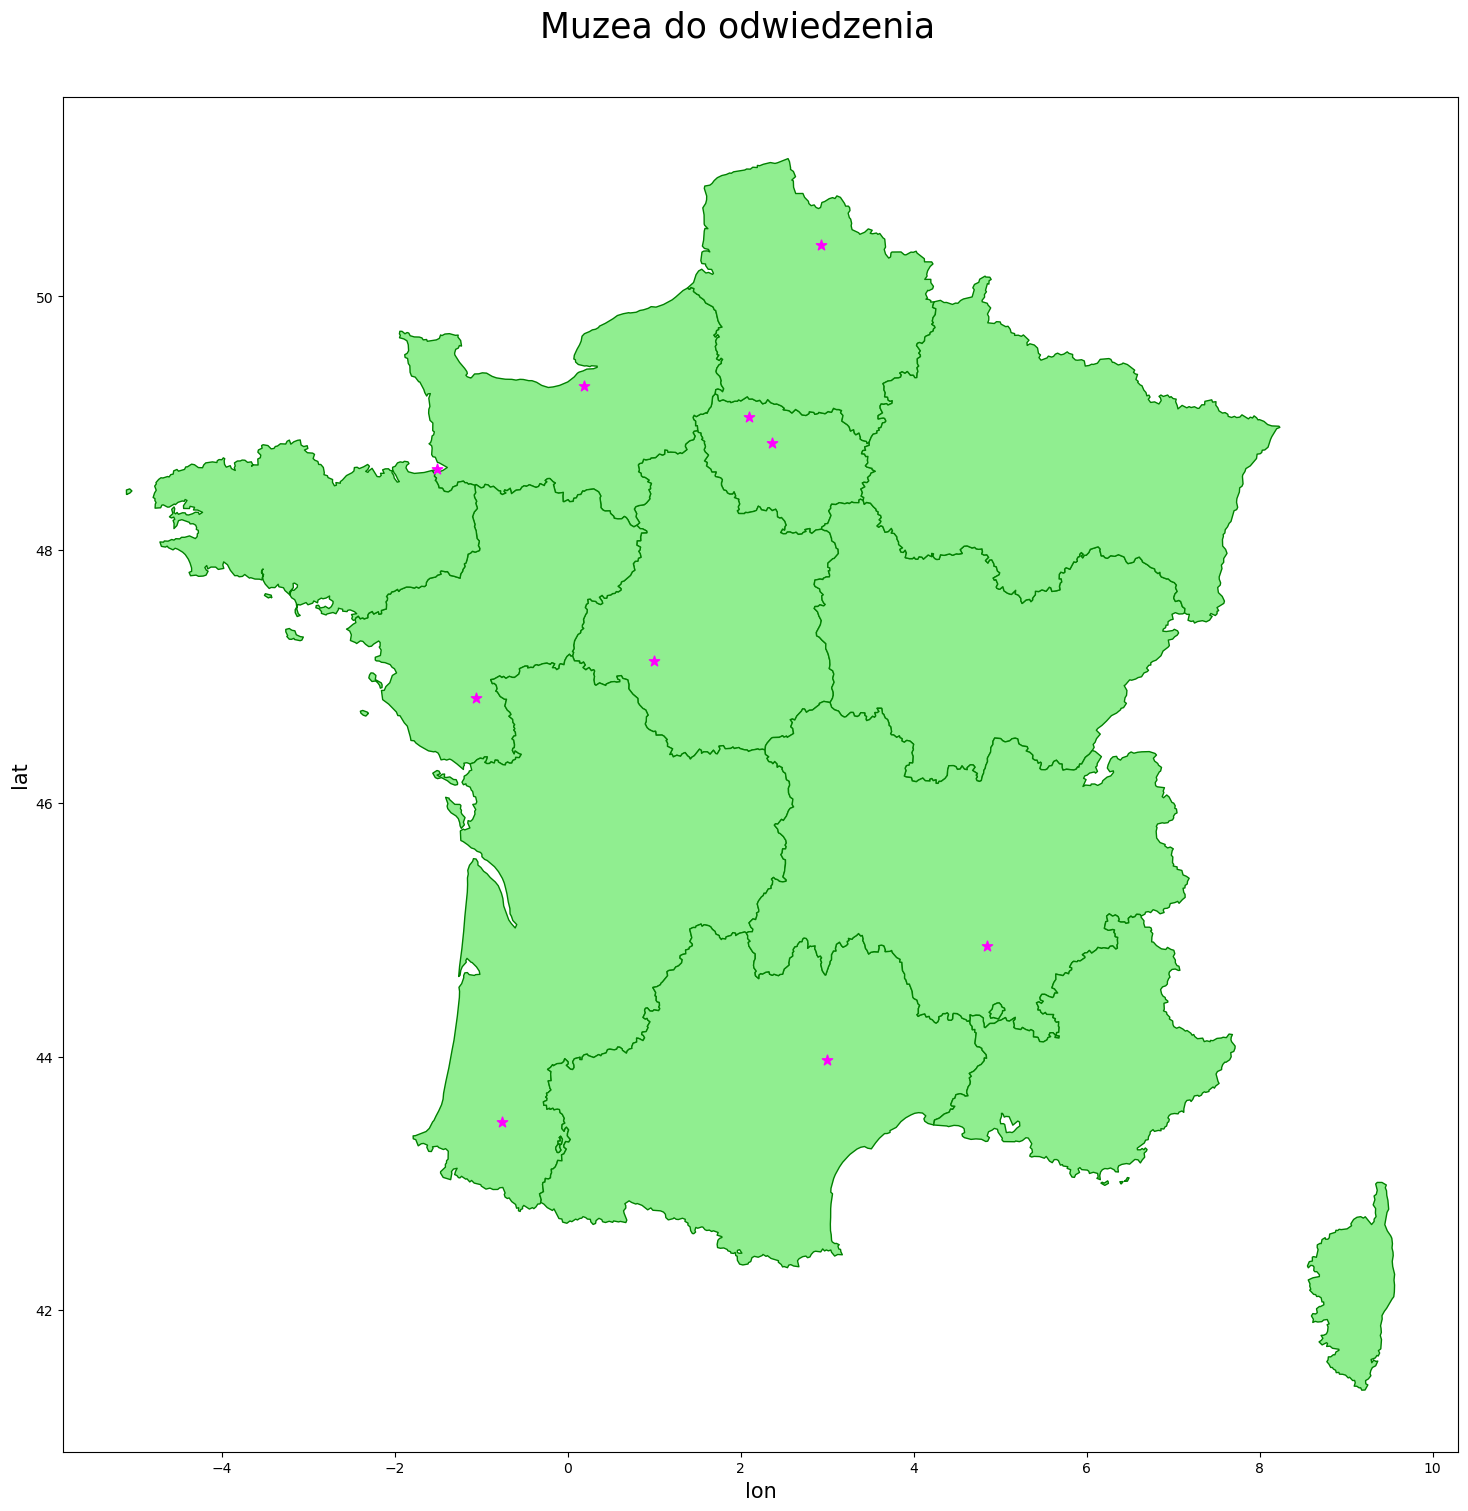

In [446]:
def visualize_data(musee_sample):
    fig, ax = plt.subplots(figsize=(18, 18),facecolor='white')
    plt.subplots_adjust(top=1)
    plt.suptitle('Muzea do odwiedzenia', fontsize=25)
    france=gpd.read_file('regions-version-simplifiee.geojson')
    france.plot(ax=ax,edgecolor='green',color='lightgreen')
    #musee_gpd=gpd.points_from_xy(x=musee_location['lat'],y=musee_location['lon'],crs='EPSG:4326')
    gdf = gpd.GeoDataFrame(musee_sample,geometry=gpd.points_from_xy(musee_sample['lon'], musee_sample['lat'],crs='EPSG:4326'))
    gdf.plot(ax=ax, marker='*', color='magenta', markersize=60) 
    plt.xlabel('lon',fontsize=15)
    plt.ylabel('lat',fontsize=15)
    return fig
fig = visualize_data(musee_sample)
fig.savefig('map1.png')

In [447]:
def calculate_distance(musee_sample):
    distances = []
    for i in range(len(musee_sample)):
        for j in range(i + 1, len(musee_sample)):
            musee1_name=musee_sample.iloc[i]['name']
            musee2_name=musee_sample.iloc[j]['name']
            if musee1_name!=musee2_name:
                coords1=(musee_sample.iloc[i]['lat'], musee_sample.iloc[i]['lon'])
                coords2=(musee_sample.iloc[j]['lat'], musee_sample.iloc[j]['lon'])

                dist=mpu.haversine_distance(coords1, coords2)
                dist=round(dist, 2)

                distances.append({'musee1': musee1_name,'musee2': musee2_name,'distance [km]': dist})
                
    distance_df = pd.DataFrame(distances)
    return distance_df

In [449]:
distance_df=calculate_distance(musee_sample)
df_head=distance_df.head()
df_tail=distance_df.tail()
df_dist=pd.concat([df_head,df_tail],axis=0)
df_dist

,musee1,musee2,distance [km]
0,Caves Roquefort Société,Aquaterra,714.98
1,Caves Roquefort Société,Calvados Experience,628.96
2,Caves Roquefort Société,Ardéche Miniatures,177.92
3,Caves Roquefort Société,Archéoscope,622.88
4,Caves Roquefort Société,Association Francis Jammes,306.78
40,Anciennes Carrières,Carrière troglodytique de Vignemont,229.30
41,Anciennes Carrières,Abbaye de la Grainetière,340.92
42,Alexandre Brongniart,Carrière troglodytique de Vignemont,216.16
43,Alexandre Brongniart,Abbaye de la Grainetière,339.12
44,Carrière troglodytique de Vignemont,Abbaye de la Grainetière,159.61


In [450]:
def create_distance_matrix(distance_df):
    museums = list(set(distance_df['musee1']).union(set(distance_df['musee2'])))
    museum_index = {museum: idx for idx, museum in enumerate(museums)}
    
    distance_matrix = np.zeros((len(museums), len(museums)))
    
    for _, row in distance_df.iterrows():
        i = museum_index[row['musee1']]
        j = museum_index[row['musee2']]
        distance_matrix[i, j] = row['distance [km]']
        distance_matrix[j, i] = row['distance [km]']
    return distance_matrix, museum_index

In [451]:
distance_matrix, museum_index=create_distance_matrix(distance_df)
distance_matrix

array([[  0.  , 141.55, 161.88, 508.78, 268.01,  29.88, 340.92, 229.3 ,
        568.55, 656.66],
       [141.55,   0.  , 232.  , 604.48, 143.85, 165.83, 289.16, 248.78,
        628.96, 649.96],
       [161.88, 232.  ,   0.  , 631.28, 375.71, 178.48, 493.59, 391.18,
        714.98, 818.54],
       [508.78, 604.48, 631.28,   0.  , 639.28, 479.86, 506.05, 388.  ,
        177.92, 473.16],
       [268.01, 143.85, 375.71, 639.28,   0.  , 284.43, 203.61, 251.68,
        622.88, 575.58],
       [ 29.88, 165.83, 178.48, 479.86, 284.43,   0.  , 339.12, 216.16,
        543.45, 642.19],
       [340.92, 289.16, 493.59, 506.05, 203.61, 339.12,   0.  , 159.61,
        448.08, 372.63],
       [229.3 , 248.78, 391.18, 388.  , 251.68, 216.16, 159.61,   0.  ,
        382.9 , 427.38],
       [568.55, 628.96, 714.98, 177.92, 622.88, 543.45, 448.08, 382.9 ,
          0.  , 306.78],
       [656.66, 649.96, 818.54, 473.16, 575.58, 642.19, 372.63, 427.38,
        306.78,   0.  ]])

In [452]:
def create_intial_population(population_size):
    population=[]
    for i in range(population_size):
        chromosome=list(range(len(museum_index)))
        random.shuffle(chromosome)
        population.append(chromosome)
    return population

In [453]:
population=create_intial_population(10)
print(population)

[[1, 5, 8, 0, 4, 2, 6, 7, 9, 3], [7, 3, 0, 1, 9, 5, 6, 4, 2, 8], [0, 5, 7, 4, 3, 6, 9, 2, 8, 1], [7, 8, 5, 4, 3, 6, 2, 9, 1, 0], [7, 5, 2, 6, 1, 8, 9, 0, 4, 3], [0, 9, 8, 6, 5, 2, 4, 3, 7, 1], [3, 1, 6, 7, 0, 2, 8, 4, 9, 5], [8, 2, 7, 6, 1, 4, 5, 0, 3, 9], [0, 5, 7, 1, 2, 6, 9, 8, 4, 3], [9, 7, 3, 4, 1, 2, 8, 5, 6, 0]]


In [454]:
def calculate_total_distance(chromosome, distance_matrix):
    total_distance = 0
    for i in range(len(chromosome)-1):
        total_distance += distance_matrix[chromosome[i], chromosome[i + 1]]
    total_distance += distance_matrix[chromosome[-1], chromosome[0]]
    return total_distance

In [455]:
def calculate_population_distances(population, distance_matrix):
    distances = []
    for chromosome in population:
        distance = calculate_total_distance(chromosome, distance_matrix)
        distances.append(distance)
    return distances

In [456]:
distances=calculate_population_distances(population, distance_matrix)
distances

[4079.77,
 4346.8,
 4319.71,
 4689.050000000001,
 4065.08,
 3722.44,
 4479.92,
 3301.8099999999995,
 3670.7599999999993,
 4425.639999999999]

In [634]:
def calculate_fitness_function(distances):
    fitness=[(1/dist) for dist in distances]
    return fitness

In [615]:
fitness=calculate_fitness_function(distances)
fitness

[245.11185679584878,
 230.0542928131039,
 231.49702179081464,
 213.26281442936198,
 245.99761874305057,
 268.64099891469033,
 223.21827175485276,
 302.86418661279725,
 272.42314942954596,
 225.95601992028273]

In [421]:
def simple_selection(population,fitness,proportion):
    fitness_population=list(zip(population,fitness))
    fitness_population.sort(key=lambda x: x[1], reverse=True)
    num_to_select=int(len(population)*proportion)
    selected_population=[chromosome for chromosome, fit in fitness_population[:num_to_select]]
    return selected_population

In [422]:
simple_selection(population,fitness,0.5)

[[4, 0, 8, 5, 9, 7, 1, 6, 2, 3],
 [3, 8, 5, 9, 0, 6, 2, 1, 7, 4],
 [7, 9, 2, 4, 8, 5, 0, 1, 6, 3],
 [4, 2, 1, 5, 7, 3, 6, 0, 9, 8],
 [0, 2, 6, 7, 3, 9, 8, 1, 4, 5]]

In [633]:
def roulette_wheel_selection(population, fitness, proportion):
    selected_population = []
    total_fitness = sum(fitness)
    total_fitness_norms = [f / total_fitness for f in fitness]
    cumulative_fitness = np.cumsum(total_fitness_norms).tolist()
    
    for _ in range(int(len(population) * proportion)):
        random_num = random.uniform(0, 1)
        for i, score in enumerate(cumulative_fitness):
            if random_num <= score:
                selected_population.append(population[i])
                break
    return selected_population

In [617]:
selected_population=roulette_wheel_selection(population,fitness,0.5)
print(selected_population)

[[1, 5, 8, 0, 4, 2, 6, 7, 9, 3], [3, 1, 6, 7, 0, 2, 8, 4, 9, 5], [1, 5, 8, 0, 4, 2, 6, 7, 9, 3], [1, 5, 8, 0, 4, 2, 6, 7, 9, 3], [1, 5, 8, 0, 4, 2, 6, 7, 9, 3]]


In [166]:
def tournament_method(population,fitness,population_size):
    selected_population=[]
    tournament_population=population.copy()
    indexes=list(range(population_size))
    for _ in range(int(population_size/2)):
        contestant1=random.choice(indexes)
        contestant2=random.choice(indexes)
        while contestant1 == contestant2:
            contestant2=random.choice(indexes)
        fit1=fitness[contestant1]
        fit2=fitness[contestant2]
        if fit1>fit2:
            selected_population.append(tournament_population[contestant1])
        else:
            selected_population.append(tournament_population[contestant2])
        indexes.remove(contestant1)
        indexes.remove(contestant2)
    return selected_population

In [165]:
tournament_method(population,fitness,10)

0.9053368597607785 0.767049219758589
1.0 0.9544525850616452
0.8078942402394795 0.8399042182662537
0.8538327878347439 0.8080509044275062
0.9417431552049371 0.8412562113389576


[[4, 2, 1, 5, 7, 3, 6, 0, 9, 8],
 [4, 0, 8, 5, 9, 7, 1, 6, 2, 3],
 [7, 3, 6, 9, 0, 2, 1, 8, 4, 5],
 [0, 2, 6, 7, 3, 9, 8, 1, 4, 5],
 [7, 9, 2, 4, 8, 5, 0, 1, 6, 3]]

In [168]:
def fill_child(child, parent, start, end, size):
    mapping = {}
    for i in range(start, end+1):
        mapping[child[i]]=parent[i]

    for i in range(size):
        if child[i]==-1:
            candidate=parent[i]
            while candidate in mapping:
                candidate=mapping[candidate]
            child[i]=candidate

In [198]:
def crossover(parent1, parent2, size, proportion):
    start=random.randint(0, size-1)
    gene_num=int(proportion*size-1)
    end=start+gene_num
    if end >= size:
        end=size-1
    child1, child2=[-1]*size, [-1]*size
    child1[start:end+1]=parent2[start:end+1]
    child2[start:end+1]=parent1[start:end+1]
    fill_child(child1, parent1, start, end, size)
    fill_child(child2, parent2, start, end, size)
    return child1, child2

In [197]:
child1,child2=crossover(selected_population[0], selected_population[1],10, 0.2)
print(selected_population[0],selected_population[1])
print(child1,child2)

[7, 9, 2, 4, 8, 5, 0, 1, 6, 3] [3, 4, 2, 9, 8, 7, 1, 6, 0, 5]
[5, 9, 2, 4, 8, 7, 0, 1, 6, 3] [3, 4, 2, 9, 8, 5, 1, 6, 0, 7]


In [195]:
def mutation(child,size):
    gene1=random.randint(0,size-1)
    gene2=random.randint(0,size-1)
    while gene1 == gene2:
        gene2=random.randint(0,size-1)
    temp=child[gene1]
    child[gene1]=child[gene2]
    child[gene2]=temp
    return child

In [199]:
mutation(child1,10)

[5, 9, 2, 4, 8, 7, 0, 1, 3, 6]

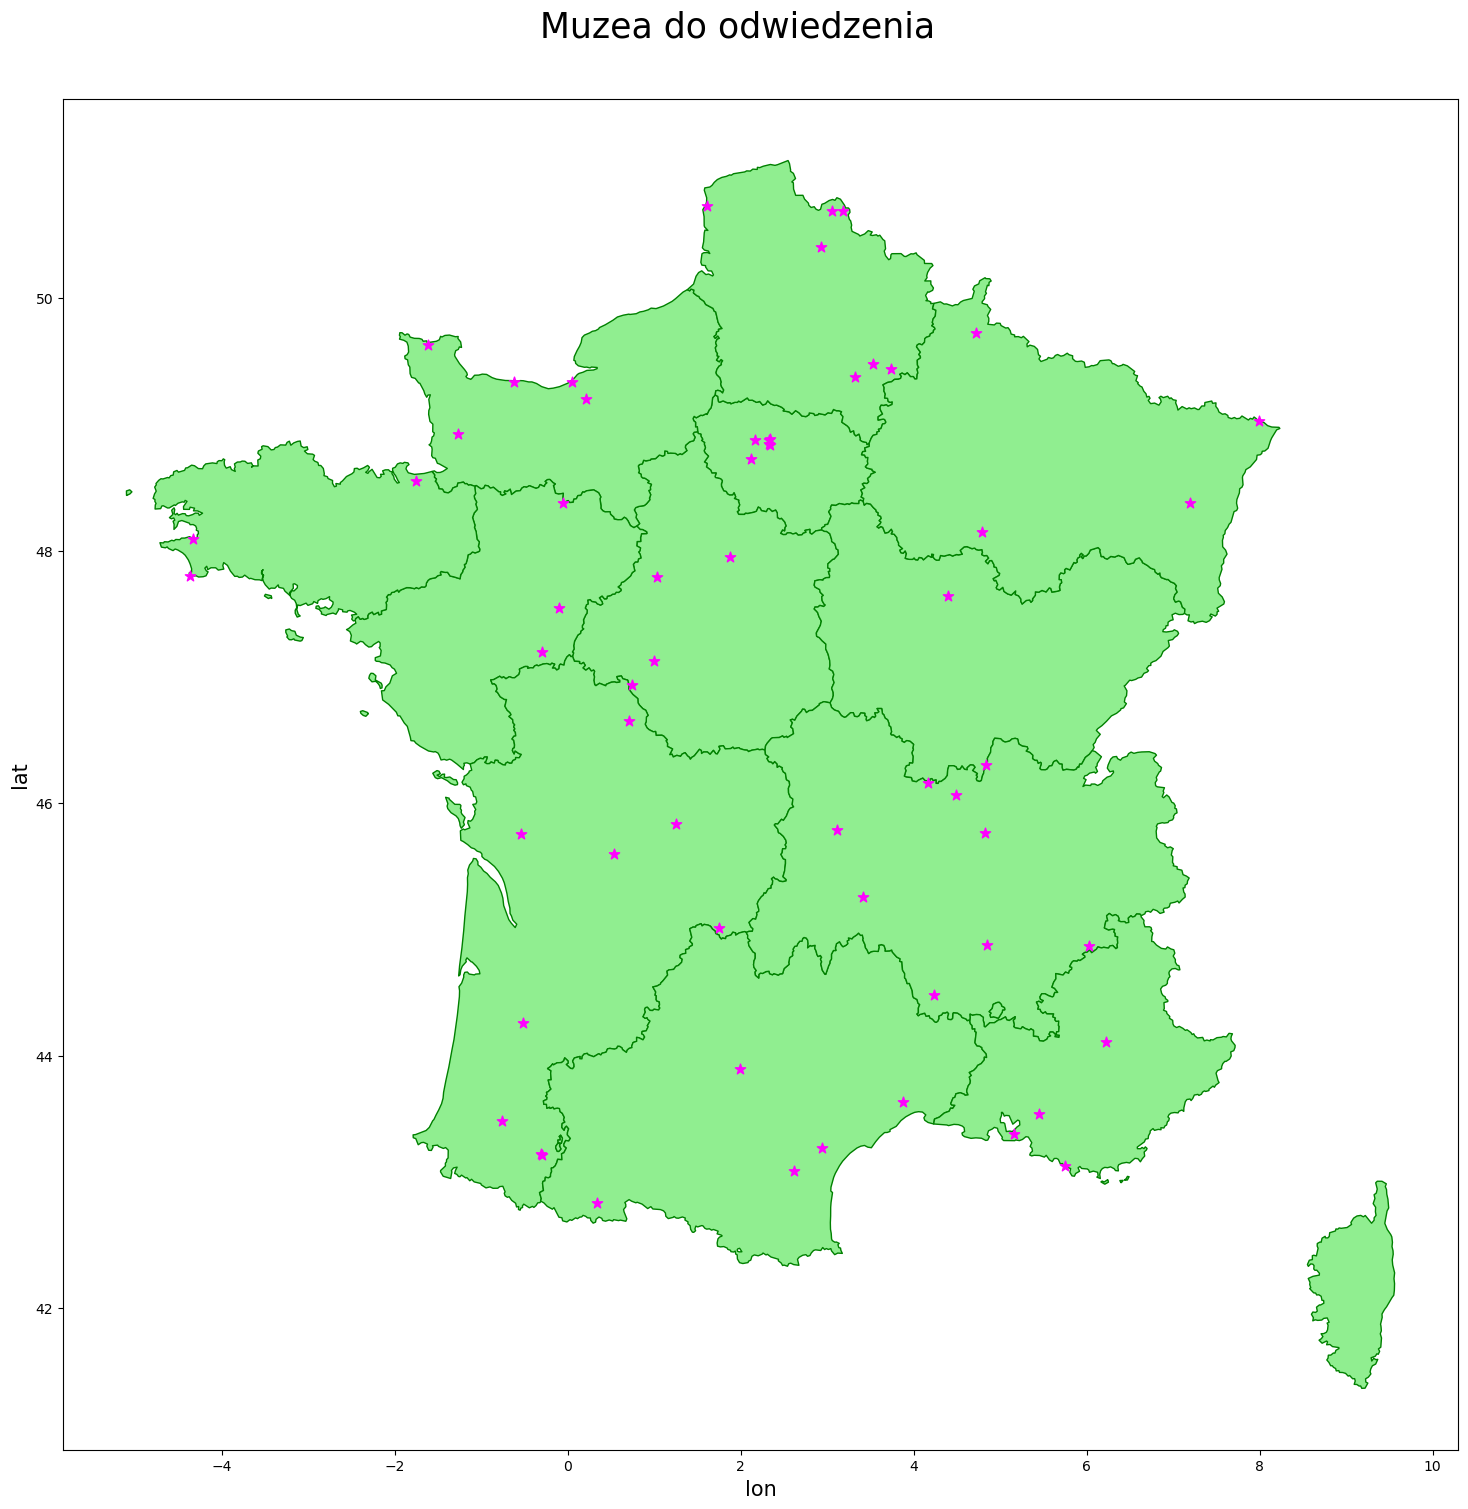

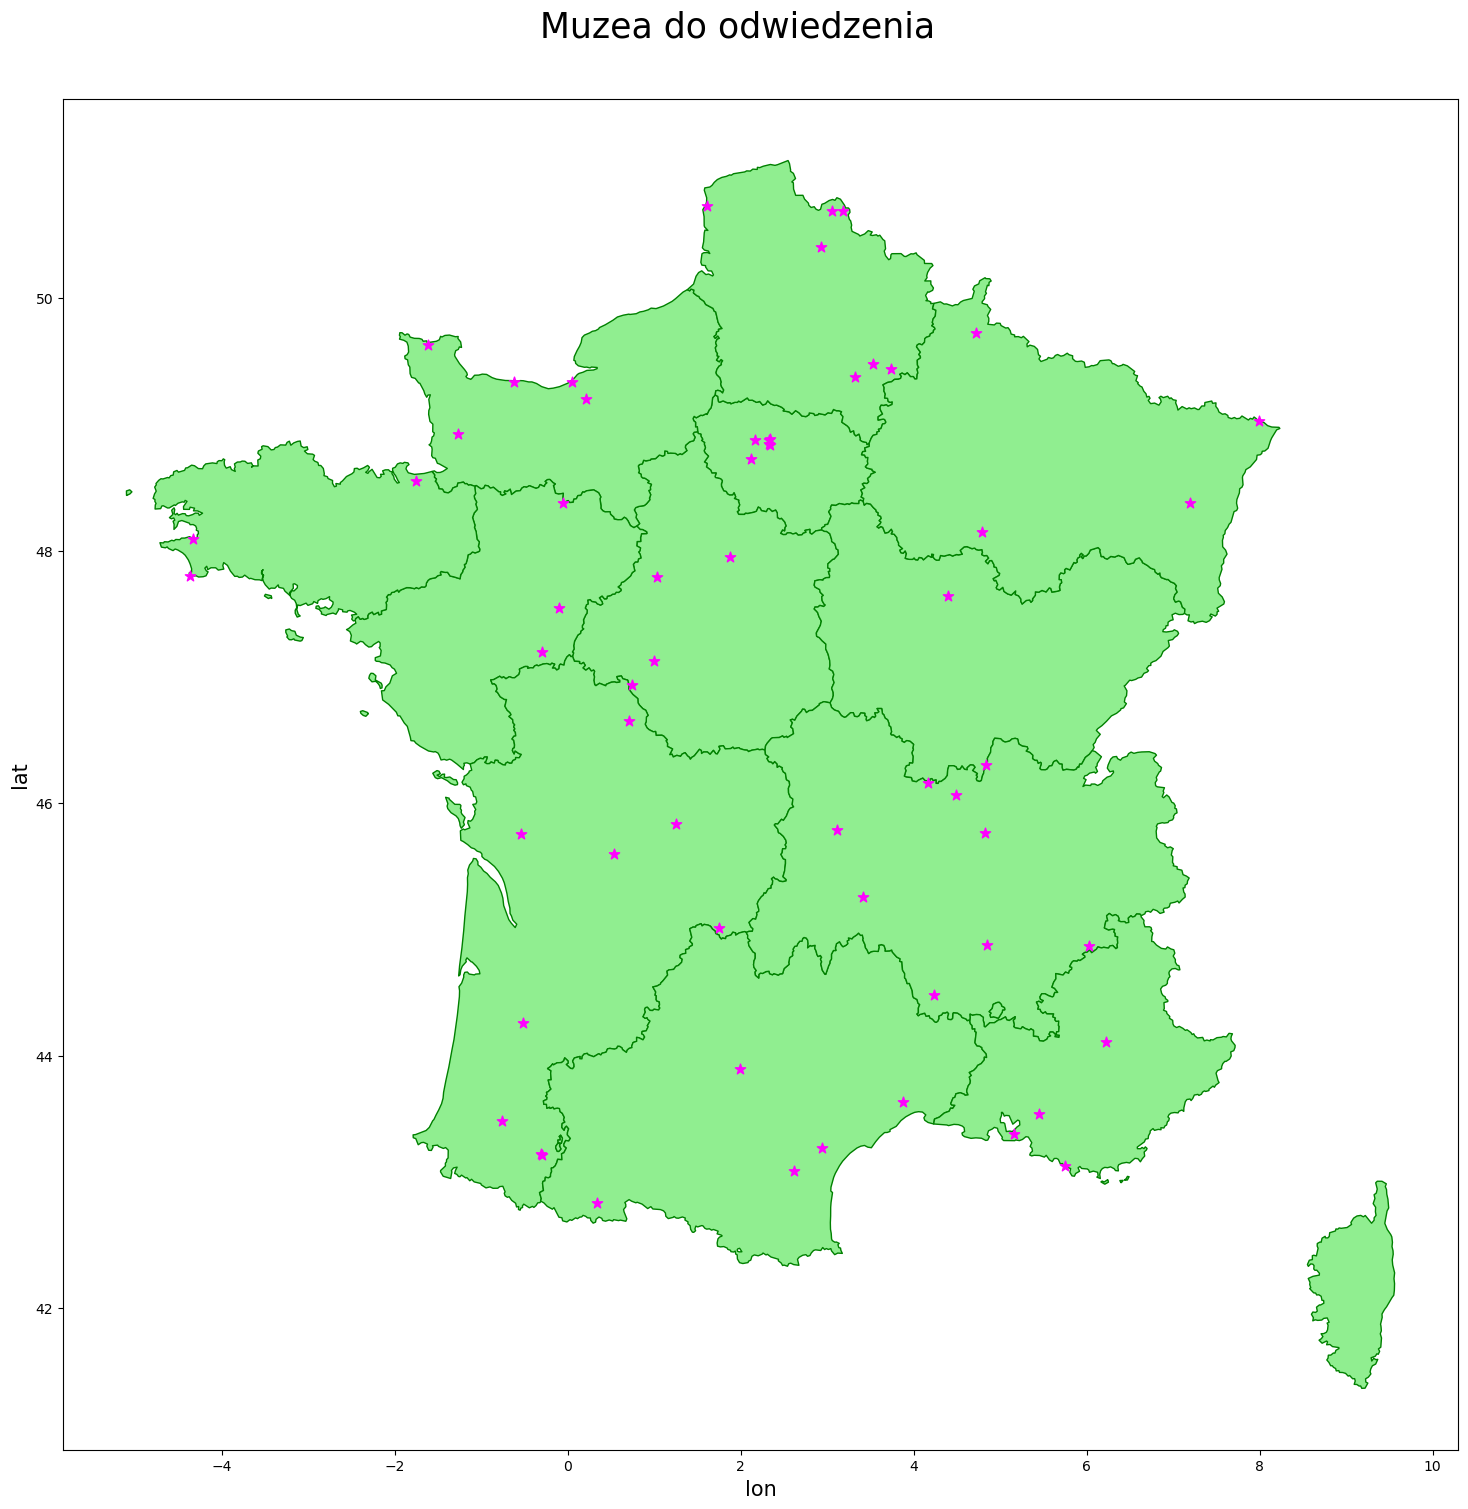

In [567]:
musee_csv='musee.txt'
size=60
musee_sample=prepare_data(musee_csv,size)
distance_df=calculate_distance(musee_sample)
distance_matrix, museum_index=create_distance_matrix(distance_df)
visualize_data(musee_sample)
fig = visualize_data(musee_sample)
fig.savefig('map1.png')

In [568]:
distance_df=calculate_distance(musee_sample)
distance_matrix, museum_index=create_distance_matrix(distance_df)

In [618]:
population_size=600
initial_population=create_intial_population(population_size)
inital_distances=calculate_population_distances(initial_population, distance_matrix)
initial_fitness=calculate_fitness_function(inital_distances)

In [671]:
def genetic_algorithm_elitism(distance_matrix, initial_population, inital_distances, initial_fitness, generations_num, selection_method, proportion, elite_parents_num, cross_proportion, crossover_prob, mutation_prob):
    start_time=time.time() 
    
    population=initial_population
    distances=inital_distances
    fitness=initial_fitness
    best_distance=float('inf')
    best_chromosome=None
    max_distances=[]
    avg_distances=[]
    min_distances=[]
    max_fitness=[]
    avg_fitness=[]
    min_fitness=[]
    
    for generation in range(generations_num):

        if selection_method=='simple':
            selected_population=simple_selection(population,fitness,proportion)
        if selection_method=='roulette':
            selected_population=roulette_wheel_selection(population,fitness,proportion)
        if selection_method=='tournament':
            selected_population=tournament_method(population,fitness,population_size)
            
        elite_indices=np.argsort(distances)[:elite_parents_num]
        elite_chromosomes=[population[i] for i in elite_indices]
        elite_distances=[distances[i] for i in elite_indices]
        
        children=[]
        distances=[]
        fitness=[]
        
        while len(children)<len(population):
            
            parent1, parent2=random.sample(selected_population, 2)
            child1, child2=parent1, parent2
            
            if random.random()<crossover_prob:
                child1, child2=crossover(parent1, parent2, len(distance_matrix), cross_proportion)
            if random.random()<mutation_prob:
                child1=mutation(child1, len(distance_matrix))
            if random.random()<mutation_prob:
                child2=mutation(child2, len(distance_matrix))
            children.extend([child1, child2])
            
        children=children[:len(population)-elite_parents_num]
        children.extend(elite_chromosomes)
        population=children[:len(population)]
        
        distances=calculate_population_distances(population, distance_matrix)
        current_best_distance=min(distances)
        
        if current_best_distance<best_distance:
            best_distance=current_best_distance
            best_chromosome=population[distances.index(current_best_distance)]
        
        fitness=calculate_fitness_function(distances)
        
    end_time=time.time()
    execution_time=end_time - start_time
    
    return best_distance, best_chromosome

In [709]:
best_distances = []
best_chromosomes = []

while best_distance>5700:
    best_distance, best_chromosome = genetic_algorithm_elitism(
        distance_matrix=distance_matrix,
        initial_population=initial_population,
        inital_distances=inital_distances,
        initial_fitness=initial_fitness,
        generations_num=400,
        selection_method='tournament',
        proportion=0.5,
        elite_parents_num=0,
        cross_proportion=0.15,
        crossover_prob=0.9,
        mutation_prob=0.1
    )

    best_distances.append(best_distance)
    best_chromosomes.append(best_chromosome)
    print(best_distance,best_chromosome)


In [687]:
for i, (distance, chromosome) in enumerate(zip(best_distances, best_chromosomes)):
    print(f'{i}: {distance} [km], route: {chromosome}')

0: 7148.14 [km], route: [44, 55, 28, 50, 7, 57, 41, 5, 12, 49, 38, 4, 40, 21, 46, 48, 3, 24, 1, 54, 19, 0, 16, 27, 6, 2, 42, 11, 14, 56, 26, 23, 18, 43, 51, 30, 36, 20, 25, 13, 33, 58, 34, 52, 59, 9, 45, 15, 35, 53, 37, 29, 10, 32, 17, 31, 22, 8, 39, 47]
1: 6102.46 [km], route: [18, 27, 3, 56, 2, 11, 42, 6, 37, 44, 7, 48, 15, 23, 13, 33, 34, 58, 52, 20, 25, 35, 53, 36, 43, 50, 41, 46, 21, 59, 9, 45, 40, 38, 4, 49, 12, 5, 55, 57, 28, 8, 47, 39, 31, 22, 10, 32, 17, 29, 26, 14, 0, 54, 1, 19, 16, 24, 30, 51]
2: 6637.289999999999 [km], route: [29, 28, 57, 55, 41, 5, 4, 38, 49, 40, 12, 21, 46, 50, 26, 51, 30, 24, 16, 11, 14, 2, 3, 27, 19, 54, 1, 0, 42, 6, 37, 44, 7, 48, 35, 25, 59, 52, 58, 34, 33, 13, 20, 45, 9, 15, 23, 53, 36, 43, 18, 56, 17, 32, 10, 22, 31, 39, 47, 8]
3: 6807.999999999999 [km], route: [48, 44, 37, 7, 55, 5, 50, 41, 12, 46, 15, 13, 33, 25, 20, 59, 58, 34, 52, 38, 4, 49, 40, 45, 9, 21, 35, 53, 43, 18, 30, 51, 24, 16, 19, 1, 54, 0, 29, 28, 57, 47, 39, 8, 31, 22, 10, 32, 17, 5

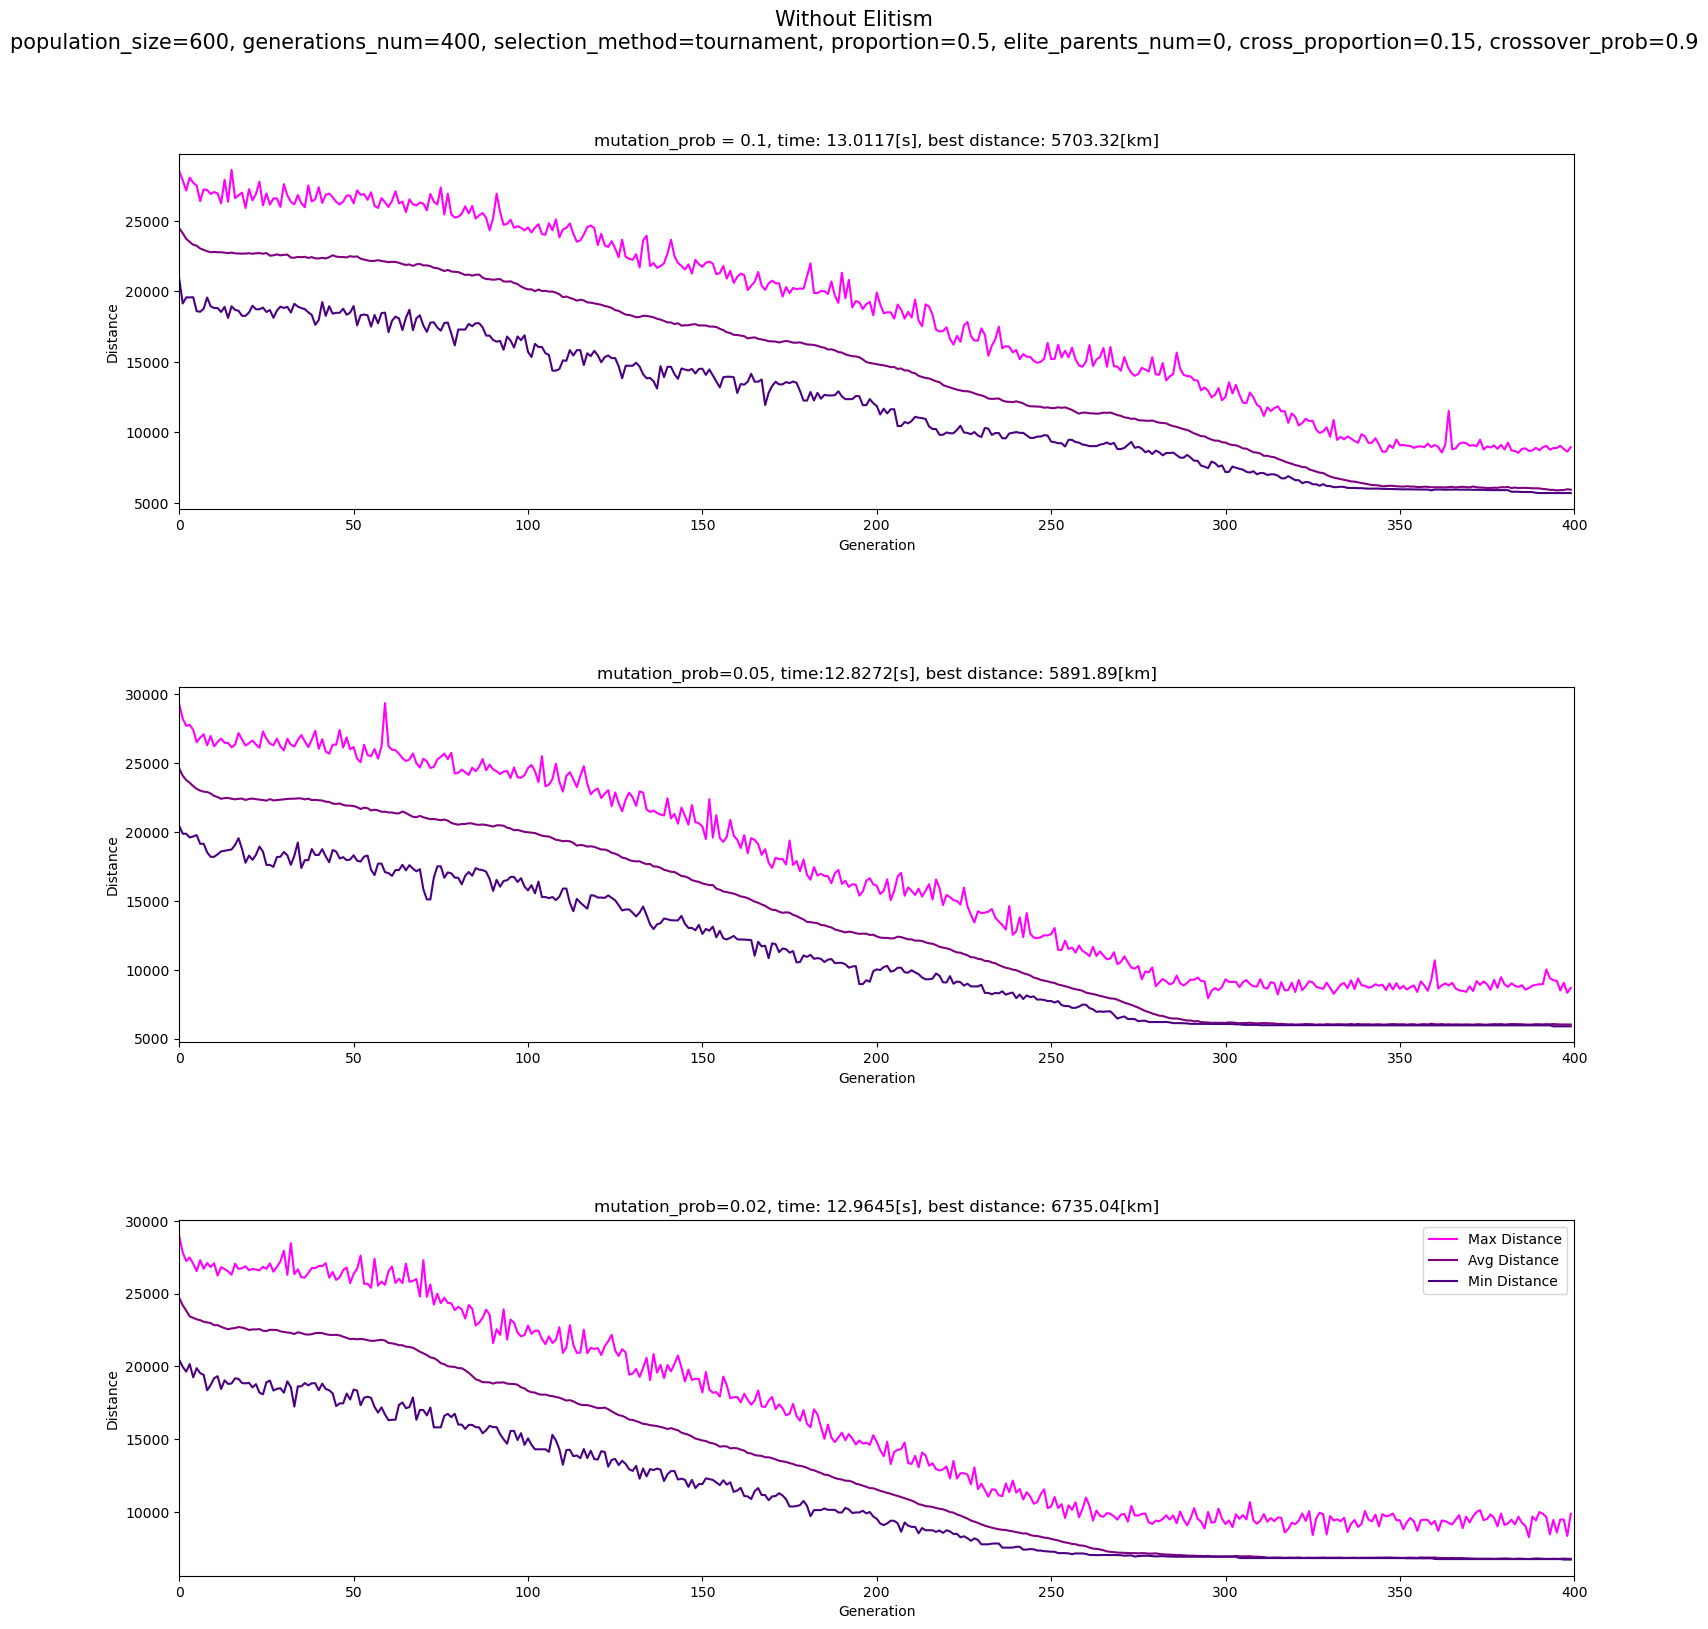

In [668]:
generations1 = range(0, len(max_distances_200))
generations2 = range(0, len(max_distances_600))
generations3 = range(0, len(max_distances_1))
fig, ax = plt.subplots(3,1,figsize=(18, 18),facecolor='white')
ax[0].plot(generations1, max_distances_200, label='Max Distance',color='magenta')
ax[0].plot(generations1, avg_distances_200, label='Avg Distance',color='purple')
ax[0].plot(generations1, min_distances_200, label='Min Distance',color='indigo')
ax[0].set_title(f'mutation_prob = 0.1, time: {execution_time_200:.4f}[s], best distance: {best_distance_200:.2f}[km]')

ax[1].plot(generations2, max_distances_600, label='Max Distance',color='magenta')
ax[1].plot(generations2, avg_distances_600, label='Avg Distance',color='purple')
ax[1].plot(generations2, min_distances_600, label='Min Distance',color='indigo')
ax[1].set_title(f'mutation_prob=0.05, time:{execution_time_600:.4f}[s], best distance: {best_distance_600:.2f}[km]')

ax[2].plot(generations3, max_distances_1, label='Max Distance',color='magenta')
ax[2].plot(generations3, avg_distances_1, label='Avg Distance',color='purple')
ax[2].plot(generations3, min_distances_1, label='Min Distance',color='indigo')
ax[2].set_title(f'mutation_prob=0.02, time: {execution_time_1:.4f}[s], best distance: {best_distance_1:.2f}[km]')

ax[0].set_xlabel('Generation',fontsize=10)
ax[0].set_ylabel('Distance',fontsize=10)
ax[1].set_xlabel('Generation',fontsize=10)
ax[1].set_ylabel('Distance',fontsize=10)
ax[2].set_xlabel('Generation',fontsize=10)
ax[2].set_ylabel('Distance',fontsize=10)

ax[0].set_xlim(0,len(max_distances_200))
ax[1].set_xlim(0,len(max_distances_600))
ax[2].set_xlim(0,len(max_distances_1))

plt.suptitle(f'Without Elitism\npopulation_size=600, generations_num=400, selection_method=tournament, proportion=0.5, elite_parents_num=0, cross_proportion=0.15, crossover_prob=0.9', fontsize=15)
plt.subplots_adjust(top=0.9, hspace=0.5)
plt.legend()
plt.show()
fig.savefig('elite1.png')

In [691]:
best_path=best_chromosomes[-1]
best_dist=best_distances[-1]

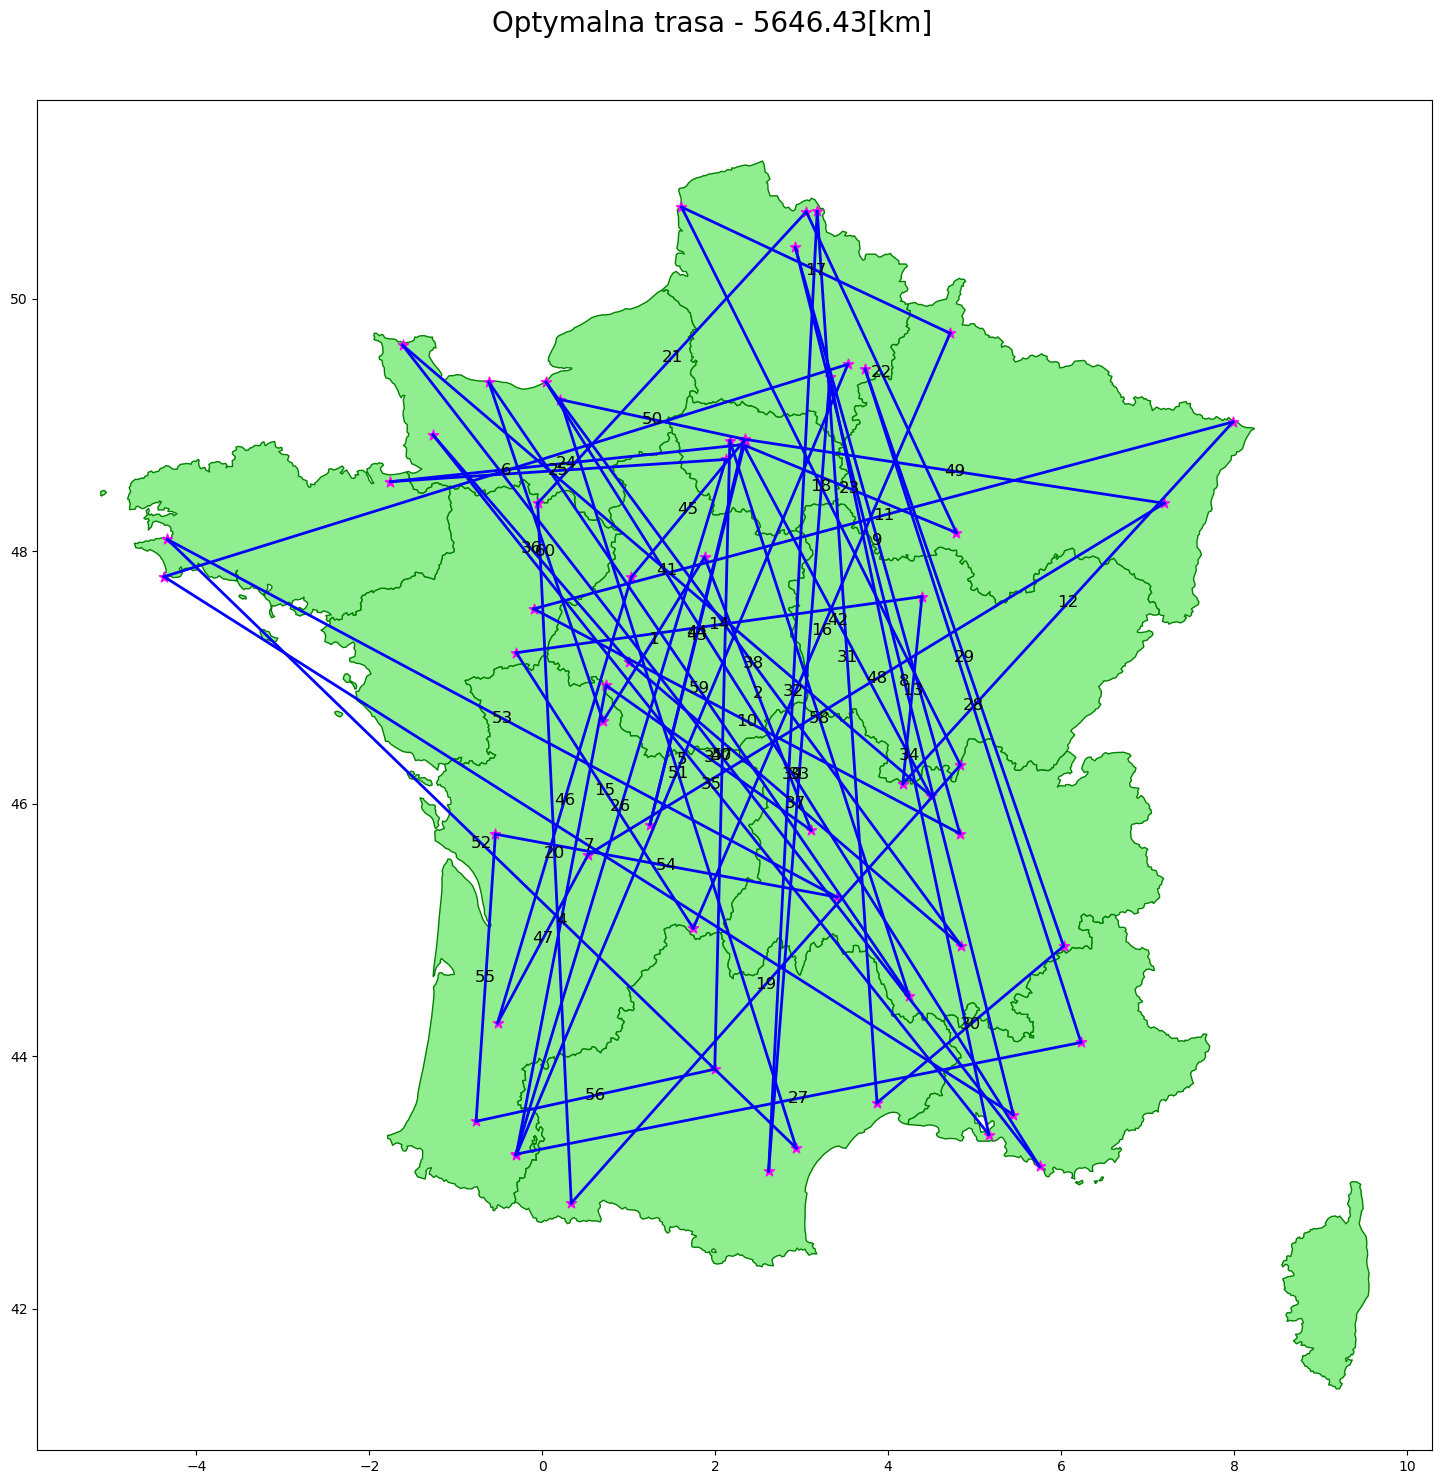

In [698]:
def visualize_path(musee_sample,best_path):
    fig, ax = plt.subplots(figsize=(18, 18),facecolor='white')
    plt.suptitle(f'Optymalna trasa - {best_dist}[km]',fontsize=20)
    plt.subplots_adjust(top=1)
    france=gpd.read_file('regions-version-simplifiee.geojson')
    france.plot(ax=ax,edgecolor='green',color='lightgreen')
    #musee_gpd=gpd.points_from_xy(x=musee_location['lat'],y=musee_location['lon'],crs='EPSG:4326')
    gdf = gpd.GeoDataFrame(musee_sample,geometry=gpd.points_from_xy(musee_sample['lon'], musee_sample['lat'],crs='EPSG:4326'))
    gdf.plot(ax=ax, marker='*', color='magenta', markersize=60) 
    for i in range(len(best_path) - 1):
        start_coords = musee_sample.iloc[best_path[i]]['coords']
        end_coords = musee_sample.iloc[best_path[i + 1]]['coords']
        line = LineString([start_coords[::-1], end_coords[::-1]])
        ax.plot(*line.xy, color='blue', linewidth=2)
        
        mid_coords = [(start_coords[0] + end_coords[0]) / 2, (start_coords[1] + end_coords[1]) / 2]
        ax.text(mid_coords[1], mid_coords[0], str(i+1), color='black', fontsize=12, ha='center', va='center')

    start_coords = musee_sample.iloc[best_path[-1]]['coords']
    end_coords = musee_sample.iloc[best_path[0]]['coords']
    line = LineString([start_coords[::-1], end_coords[::-1]]) 
    ax.plot(*line.xy, color='blue', linewidth=2)
    ax.text((start_coords[1] + end_coords[1]) / 2, (start_coords[0] + end_coords[0]) / 2, str(len(best_path)), color='black', fontsize=12, ha='center', va='center')

    plt.show()
    return fig

fig=visualize_path(musee_sample,best_path)
fig.savefig('map1.png')

In [707]:
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import LineString
import imageio
import pandas as pd

def visualize_data(musee_sample, best_path, gif_path='animation.gif'):
    fig, ax = plt.subplots(figsize=(18, 18), facecolor='white')
    plt.suptitle('Muzea we Francji')
    
    france = gpd.read_file('regions-version-simplifiee.geojson')
    france.plot(ax=ax, edgecolor='green', color='lightgreen')
    
    gdf = gpd.GeoDataFrame(musee_sample, geometry=gpd.points_from_xy(musee_sample['lon'], musee_sample['lat'], crs='EPSG:4326'))
    gdf.plot(ax=ax, marker='*', color='magenta', markersize=60)
    
    frames = []
    
    for i in range(len(best_path) - 1):
        fig, ax = plt.subplots(figsize=(18, 18), facecolor='white')
        plt.suptitle('Muzea we Francji')
        france.plot(ax=ax, edgecolor='green', color='lightgreen')
        gdf.plot(ax=ax, marker='*', color='magenta', markersize=60)
        
        for j in range(i + 1):
            start_coords = musee_sample.iloc[best_path[j]]['coords']
            end_coords = musee_sample.iloc[best_path[j + 1]]['coords']
            line = LineString([start_coords[::-1], end_coords[::-1]]) # Zamiana miejscami lat, lon na lon, lat
            ax.plot(*line.xy, color='blue', linewidth=2)
            mid_coords = [(start_coords[0] + end_coords[0]) / 2, (start_coords[1] + end_coords[1]) / 2]
            ax.text(mid_coords[1], mid_coords[0], str(j + 1), color='black', fontsize=12, ha='center', va='center')

        if i == len(best_path) - 2:
            start_coords = musee_sample.iloc[best_path[-1]]['coords']
            end_coords = musee_sample.iloc[best_path[0]]['coords']
            line = LineString([start_coords[::-1], end_coords[::-1]])
            ax.plot(*line.xy, color='blue', linewidth=2)
            ax.text((start_coords[1] + end_coords[1]) / 2, (start_coords[0] + end_coords[0]) / 2, str(len(best_path)), color='black', fontsize=12, ha='center', va='center')
        
        filename = f'frame_{i}.png'
        plt.savefig(filename)
        frames.append(filename)
        plt.close()
    
    with imageio.get_writer(gif_path, mode='I', duration=1) as writer:
        for frame in frames:
            image = imageio.imread(frame)
            writer.append_data(image)

    print(f'GIF saved to {gif_path}')


#visualize_data(musee_sample, best_path)
